In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, FunctionTransformer, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
import os
import fiona

In [2]:
fire_data = gpd.read_file("../total_fire.geojson")
ain_data = gpd.read_file("../datasets_par_departement/departement-01-ain-original.geojson")
doubs_data = gpd.read_file("../datasets_par_departement/departement-25-doubs-original.geojson")
yvelines_data = gpd.read_file("../datasets_par_departement/departement-78-yvelines-original.geojson")

In [3]:
def calculer_duree(data, colonne_debut, colonne_fin):
    data[colonne_debut] = pd.to_datetime(data[colonne_debut], errors='coerce')
    data[colonne_fin] = pd.to_datetime(data[colonne_fin], errors='coerce')

    data['duree'] = data[colonne_fin] - data[colonne_debut]

    return data

def cyclical_encoding(X, max_value):
    return np.column_stack((
        np.sin(2 * np.pi * X / max_value),
        np.cos(2 * np.pi * X / max_value)
    ))

def season_encoding(month):
    if month in [12, 1, 2]:
        return 0  # Hiver
    elif month in [3, 4, 5]:
        return 1  # Printemps
    elif month in [6, 7, 8]:
        return 2  # Été
    else:
        return 3  # Automne

In [4]:
fire_data = calculer_duree(fire_data, 'date_debut', 'date_fin')
fire_data['centroid'] = fire_data.geometry.centroid
fire_data['centroid_lon'] = fire_data['centroid'].x
fire_data['centroid_lat'] = fire_data['centroid'].y
fire_data['date_debut'] = pd.to_datetime(fire_data['date_debut'], errors='coerce')
fire_data['hour'] = fire_data['date_debut'].dt.hour
fire_data['date'] = pd.to_datetime(fire_data['date'], errors='coerce')
fire_data['month'] = fire_data['date'].dt.month
fire_data['duree'] = pd.to_timedelta(fire_data['duree'], errors='coerce')
fire_data['duree_minutes'] = fire_data['duree'].dt.total_seconds() / 60
fire_data['weekday'] = fire_data['date'].dt.weekday
fire_data['season'] = fire_data['month'].apply(season_encoding)
fire_data['hour_sin'] = np.sin(2 * np.pi * fire_data['hour'] / 24)
fire_data['hour_cos'] = np.cos(2 * np.pi * fire_data['hour'] / 24)
fire_data['month_sin'] = np.sin(2 * np.pi * fire_data['month'] / 12)
fire_data['month_cos'] = np.cos(2 * np.pi * fire_data['month'] / 12)
fire_data['weekday_sin'] = np.sin(2 * np.pi * fire_data['weekday'] / 7)
fire_data['weekday_cos'] = np.cos(2 * np.pi * fire_data['weekday'] / 7)

doubs_data = calculer_duree(doubs_data, 'date_debut', 'date_fin')
doubs_data['centroid'] = doubs_data.geometry.centroid
doubs_data['centroid_lon'] = doubs_data['centroid'].x
doubs_data['centroid_lat'] = doubs_data['centroid'].y
doubs_data['date_debut'] = pd.to_datetime(doubs_data['date_debut'], errors='coerce')
doubs_data['hour'] = doubs_data['date_debut'].dt.hour
doubs_data['date'] = pd.to_datetime(doubs_data['date'], errors='coerce')
doubs_data['month'] = doubs_data['date'].dt.month
doubs_data['weekday'] = doubs_data['date'].dt.weekday
doubs_data['season'] = doubs_data['month'].apply(season_encoding)
doubs_data['hour_sin'] = np.sin(2 * np.pi * doubs_data['hour'] / 24)
doubs_data['hour_cos'] = np.cos(2 * np.pi * doubs_data['hour'] / 24)
doubs_data['month_sin'] = np.sin(2 * np.pi * doubs_data['month'] / 12)
doubs_data['month_cos'] = np.cos(2 * np.pi * doubs_data['month'] / 12)
doubs_data['weekday_sin'] = np.sin(2 * np.pi * doubs_data['weekday'] / 7)
doubs_data['weekday_cos'] = np.cos(2 * np.pi * doubs_data['weekday'] / 7)

ain_data = calculer_duree(ain_data, 'date_debut', 'date_fin')
ain_data['centroid'] = ain_data.geometry.centroid
ain_data['centroid_lon'] = ain_data['centroid'].x
ain_data['centroid_lat'] = ain_data['centroid'].y
ain_data['date_debut'] = pd.to_datetime(ain_data['date_debut'], errors='coerce')
ain_data['hour'] = ain_data['date_debut'].dt.hour
ain_data['date'] = pd.to_datetime(ain_data['date'], errors='coerce')
ain_data['month'] = ain_data['date'].dt.month
ain_data['weekday'] = ain_data['date'].dt.weekday
ain_data['season'] = ain_data['month'].apply(season_encoding)
ain_data['hour_sin'] = np.sin(2 * np.pi * ain_data['hour'] / 24)
ain_data['hour_cos'] = np.cos(2 * np.pi * ain_data['hour'] / 24)
ain_data['month_sin'] = np.sin(2 * np.pi * ain_data['month'] / 12)
ain_data['month_cos'] = np.cos(2 * np.pi * ain_data['month'] / 12)
ain_data['weekday_sin'] = np.sin(2 * np.pi * ain_data['weekday'] / 7)
ain_data['weekday_cos'] = np.cos(2 * np.pi * ain_data['weekday'] / 7)

yvelines_data = calculer_duree(yvelines_data, 'date_debut', 'date_fin')
yvelines_data['centroid'] = yvelines_data.geometry.centroid
yvelines_data['centroid_lon'] = yvelines_data['centroid'].x
yvelines_data['centroid_lat'] = yvelines_data['centroid'].y
yvelines_data['date_debut'] = pd.to_datetime(yvelines_data['date_debut'], errors='coerce')
yvelines_data['hour'] = yvelines_data['date_debut'].dt.hour
yvelines_data['date'] = pd.to_datetime(yvelines_data['date'], errors='coerce')
yvelines_data['month'] = yvelines_data['date'].dt.month
yvelines_data['weekday'] = yvelines_data['date'].dt.weekday
yvelines_data['season'] = yvelines_data['month'].apply(season_encoding)
yvelines_data['hour_sin'] = np.sin(2 * np.pi * yvelines_data['hour'] / 24)
yvelines_data['hour_cos'] = np.cos(2 * np.pi * yvelines_data['hour'] / 24)
yvelines_data['month_sin'] = np.sin(2 * np.pi * yvelines_data['month'] / 12)
yvelines_data['month_cos'] = np.cos(2 * np.pi * yvelines_data['month'] / 12)
yvelines_data['weekday_sin'] = np.sin(2 * np.pi * yvelines_data['weekday'] / 7)
yvelines_data['weekday_cos'] = np.cos(2 * np.pi * yvelines_data['weekday'] / 7)

<ipython-input-4-39758bbd5975>:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  fire_data['centroid'] = fire_data.geometry.centroid
<ipython-input-4-39758bbd5975>:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  doubs_data['centroid'] = doubs_data.geometry.centroid
<ipython-input-4-39758bbd5975>:38: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ain_data['centroid'] = ain_data.geometry.centroid
<ipython-input-4-39758bbd5975>:55: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to

In [5]:
fire_data.columns

Index(['hex_id', 'raison_sortie', 'date_debut', 'date_fin', 'label', 'year',
       'date', 'departement', 'geometry', 'duree', 'centroid', 'centroid_lon',
       'centroid_lat', 'hour', 'month', 'duree_minutes', 'weekday', 'season',
       'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'weekday_sin',
       'weekday_cos'],
      dtype='object')

In [5]:
doubs_data['log_duree_minutes'] = np.log1p(doubs_data['duree_minutes'])

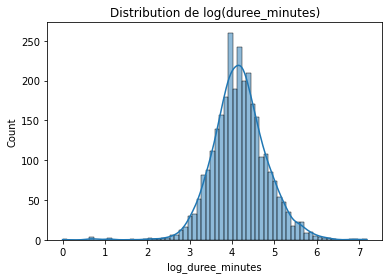

In [6]:
sns.histplot(doubs_data['log_duree_minutes'], kde=True)
plt.title("Distribution de log(duree_minutes)")
plt.show()

In [8]:
features = [
    'centroid_lon', 'centroid_lat', 
    'hour_sin', 'hour_cos', 
    'month_sin', 'month_cos', 
    'weekday_sin', 'weekday_cos', 
    'season'
]
X = doubs_data[features]
y = doubs_data['log_duree_minutes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [11]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [12]:
y_pred_log = model.predict(X_test)

In [13]:
y_pred = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test)

In [17]:
mae = mean_absolute_error(y_test_orig, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))

print(f"MAE : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

MAE : 36.57
RMSE : 76.69


In [15]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='neg_mean_absolute_error')
grid_search.fit(X_train, y_train)

print("Meilleurs hyperparamètres :", grid_search.best_params_)
best_model = grid_search.best_estimator_

Meilleurs hyperparamètres : {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}


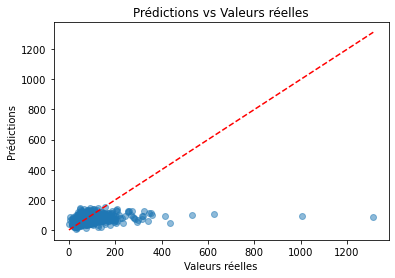

In [16]:
plt.scatter(y_test_orig, y_pred, alpha=0.5)
plt.plot([0, max(y_test_orig)], [0, max(y_test_orig)], color='red', linestyle='--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("Prédictions vs Valeurs réelles")
plt.show()

In [1]:
# Déterminer le seuil du 90e percentile
percentile_90 = meteo_doubs['duree_minutes'].quantile(0.90)

# Filtrer les données pour garder uniquement les 90 % les plus bas
filtered_data = meteo_doubs[meteo_doubs['duree_minutes'] <= percentile_90]

# Affichage des dimensions avant et après
print(f"Dimensions originales : {meteo_doubs.shape}")
print(f"Dimensions après suppression des 10 % les plus hauts : {filtered_data.shape}")

NameError: name 'meteo_doubs' is not defined